In [1]:
# Session 13

In [2]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
import scipy.stats as stats

In [17]:
import os

print(os.getcwd())

C:\Users\rk307


In [20]:
import os

for root, dirs, files in os.walk(r'C:\Users\rk307'):
    for file in files:
        if 'cp_data_demo' in file.lower():
            print(os.path.join(root, file))

C:\Users\rk307\AppData\Local\Packages\5319275A.WhatsAppDesktop_cv1g1gvanyjgm\LocalState\sessions\DD86D2BD2C019E1D43E7BB74EAEE6223FE6FB74F\transfers\2026-35\cp_data_demo.csv
C:\Users\rk307\AppData\Roaming\Microsoft\Windows\Recent\cp_data_demo.lnk
C:\Users\rk307\OneDrive\Documents\cp_data_demo.csv
C:\Users\rk307\OneDrive\Documents\IT\cp_data_demo.csv


In [21]:
import pandas as pd

df = pd.read_csv(r'C:\Users\rk307\AppData\Local\Packages\5319275A.WhatsAppDesktop_cv1g1gvanyjgm\LocalState\sessions\DD86D2BD2C019E1D43E7BB74EAEE6223FE6FB74F\transfers\2026-35\cp_data_demo.csv')

print(df)

     Formula  Temperature  Heat_Capacity
0       B2O3       1400.0        134.306
1       B2O3       1300.0        131.294
2       B2O3       1200.0        128.072
3       B2O3       1100.0        124.516
4       B2O3       1000.0        120.625
...      ...          ...            ...
4572     Zr1        450.0         26.246
4573     Zr1        400.0         25.935
4574     Zr1        350.0         25.606
4575     Zr1        300.0            NaN
4576     Zr1        298.0         25.202

[4577 rows x 3 columns]


In [22]:
print(f"Initial row count: {len(df)}")

Initial row count: 4577


In [23]:
# Rename columns to standard schema (formula, T, Cp)[cite: 16]
df = df.rename(columns={'Formula': 'formula', 'Temperature': 'T', 'Heat_Capacity': 'Cp'})

In [24]:
count_before_dropna = len(df)

In [25]:
df = df.dropna(subset=['formula', 'T', 'Cp'])

In [26]:
print(f"Rows dropped due to NaN: {count_before_dropna - len(df)}")

Rows dropped due to NaN: 13


In [27]:
valid_mask = (df['T'] >= 0) & (df['Cp'] >= 0)

In [28]:
dropped_unphysical = (~valid_mask).sum()

In [29]:
df_clean = df[valid_mask].copy()

In [30]:
print(f"Rows dropped due to unphysical values (T < 0 or Cp < 0): {dropped_unphysical}")

Rows dropped due to unphysical values (T < 0 or Cp < 0): 0


In [31]:
print(f"Final cleaned dataset row count: {len(df_clean)}")

Final cleaned dataset row count: 4564


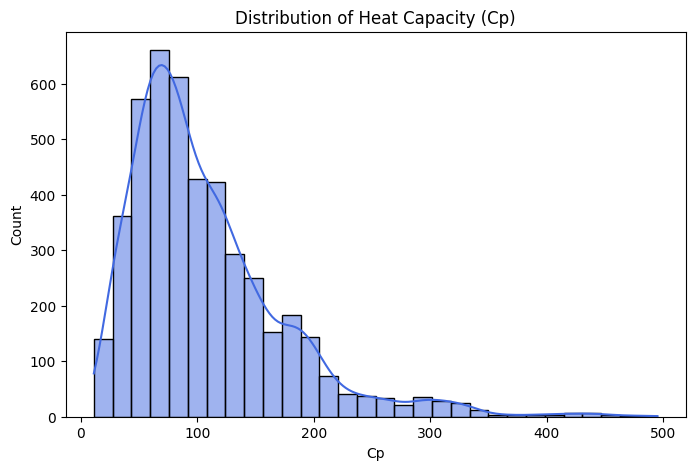

In [32]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['Cp'], kde=True, bins=30, color='royalblue')
plt.title('Distribution of Heat Capacity (Cp)')
plt.xlabel('Cp')
plt.ylabel('Count')
plt.show()

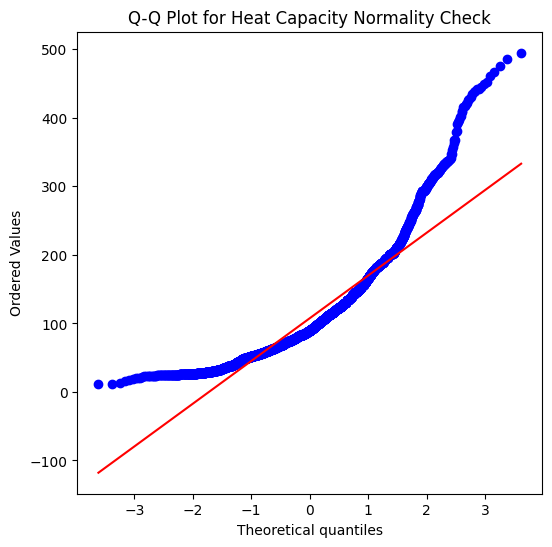

In [33]:
# 6. Perform a Q-Q normality check[cite: 16]
plt.figure(figsize=(6, 6))
stats.probplot(df_clean['Cp'], dist="norm", plot=plt)
plt.title('Q-Q Plot for Heat Capacity Normality Check')
plt.show()

In [34]:
# Save the cleaned dataset deliverable
df_clean.to_csv('cleaned_cp_dataset.csv', index=False)
print("✅ Cleaned Cp dataset successfully saved and ready for commit.")

✅ Cleaned Cp dataset successfully saved and ready for commit.


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
df = pd.read_csv('cleaned_cp_dataset.csv')

In [37]:
sample_materials = df['formula'].unique()[:5]

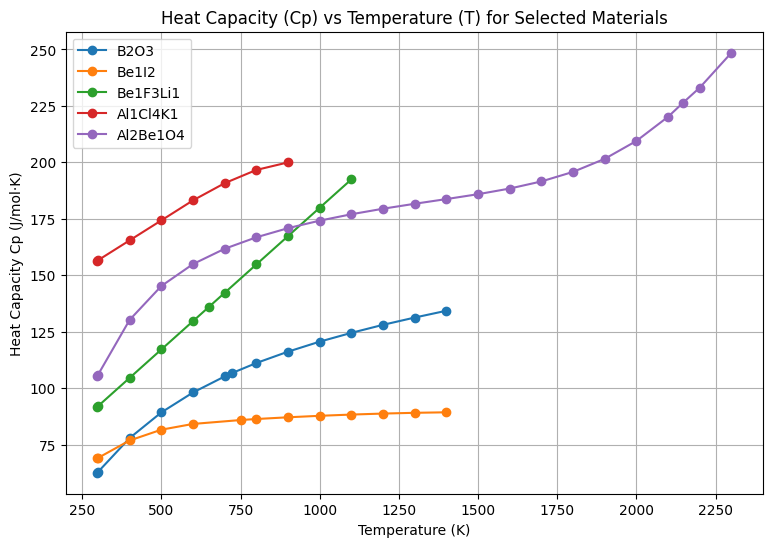

In [38]:
plt.figure(figsize=(9, 6))
for mat in sample_materials:
    subset = df[df['formula'] == mat]
    plt.plot(subset['T'], subset['Cp'], marker='o', label=mat)

plt.title('Heat Capacity (Cp) vs Temperature (T) for Selected Materials')
plt.xlabel('Temperature (K)')
plt.ylabel('Heat Capacity Cp (J/mol·K)')
plt.legend()
plt.grid(True)
plt.show()

In [39]:
def classify_family(formula):
    if 'O' in formula and 'C' not in formula and 'N' not in formula:
        return 'Oxide'
    elif 'C' in formula:
        return 'Carbide'
    elif 'N' in formula:
        return 'Nitride'
    else:
        return 'Other'

In [40]:
df['family'] = df['formula'].apply(classify_family)
df_grouped = df[df['family'].isin(['Oxide', 'Carbide', 'Nitride'])]

In [41]:
family_stats = df_grouped.groupby(['family', 'T'])['Cp'].agg(['mean', 'std']).reset_index()

In [42]:
print("✅ Chemical family grouping and statistical aggregation complete.")

✅ Chemical family grouping and statistical aggregation complete.
